In [ ]:
!pip install opencv-contrib-python

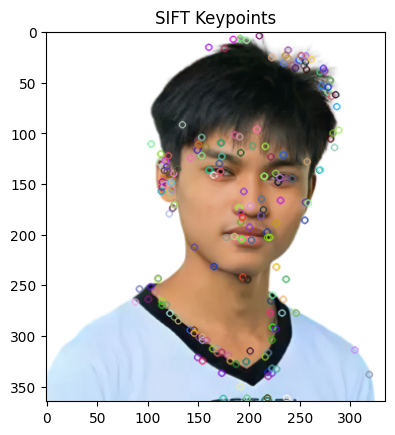

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('Juliano.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(gray_image, None)

# Draw keypoints on the image
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None)

# Display the image with keypoints
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('SIFT Keypoints')
plt.show()

In [ ]:
!pip uninstall opencv-python opencv-contrib-python

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Would remove:
    /usr/local/lib/python3.10/dist-packages/cv2/*
    /usr/local/lib/python3.10/dist-packages/opencv_python-4.10.0.84.dist-info/*
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libQt5Core-e6d3f451.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libQt5Gui-5dea4132.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libQt5Test-d435aae7.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libQt5Widgets-e392eaf8.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libQt5XcbQpa-3bf8a55a.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libX11-xcb-0e257303.so.1.0.0
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libXau-00ec42fe.so.6.0.0
    /usr/local/lib/python3.10/dist-packages/opencv_python.libs/libavcodec-9aae324f.so.59.37.100
    /usr/loca

In [ ]:
sudo apt-get update
sudo apt-get install build-essential cmake git libgtk2.0-dev pkg-config libavcodec-dev libavformat-dev libswscale-dev
sudo apt-get install python3-dev python3-numpy libtbb2 libtbb-dev libjpeg-dev libpng-dev libtiff-dev
sudo apt-get install libdc1394-22-dev libxine2-dev libv4l-dev v4l-utils
sudo apt-get install libgstreamer1.0-dev libgstreamer-plugins-base1.0-dev


SyntaxError: invalid syntax (<ipython-input-9-d01b6aff2857>, line 1)

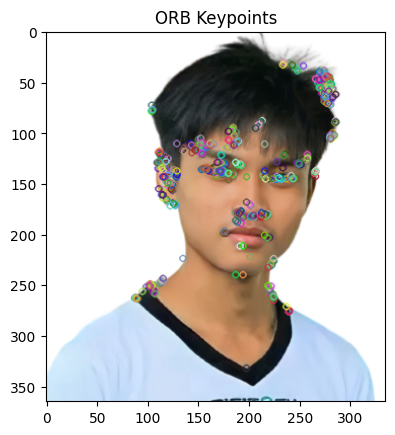

In [ ]:

# Load the image
image
cv2.imread('Juliano.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Initialize ORB detector
orb = cv2.ORB_create()

# Detect keypoints and descriptors
keypoints, descriptors = orb.detectAndCompute(gray_image, None)

# Draw keypoints on the image
image_with_keypoints = cv2.drawKeypoints (image, keypoints, None)

# Display the image with keypoints
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('ORB Keypoints')
plt.show()

# **Feature Matching**

Number of matches: 50


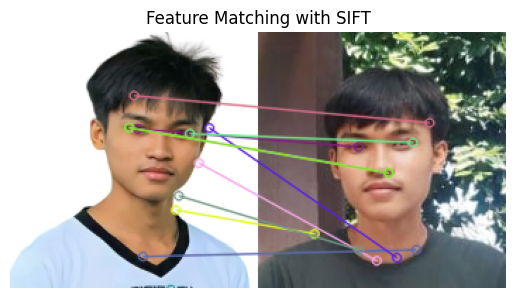

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the two images
image1 = cv2.imread("Juliano.png")
image2 = cv2.imread("Juliano.jpg")

# Check if the images are loaded correctly
if image1 is None or image2 is None:
    print("Error: One or both images could not be loaded. Check the file paths.")
    exit()

# Resize both images to the same size (use the size of the smaller image)
height1, width1 = image1.shape[:2]
height2, width2 = image2.shape[:2]

# Determine the new size (smallest height and width of both images)
new_height = min(height1, height2)
new_width = min(width1, width2)

# Resize both images
image1_resized = cv2.resize(image1, (new_width, new_height))
image2_resized = cv2.resize(image2, (new_width, new_height))

# Initialize SIFT Detector
sift = cv2.SIFT_create()

# Find the keypoints and descriptors with SIFT
keypoints1, descriptors1 = sift.detectAndCompute(image1_resized, None)
keypoints2, descriptors2 = sift.detectAndCompute(image2_resized, None)

# Initialize the Matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match descriptors
matches = bf.match(descriptors1, descriptors2)

# Print the number of matches
print(f"Number of matches: {len(matches)}")

# Sort matches by distance (Best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# Draw the matches
image_matches = cv2.drawMatches(image1_resized, keypoints1, image2_resized, keypoints2, matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the image with matches
plt.imshow(cv2.cvtColor(image_matches, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching with SIFT")
plt.axis('off')
plt.show()


# **Applications of Feature Matching**

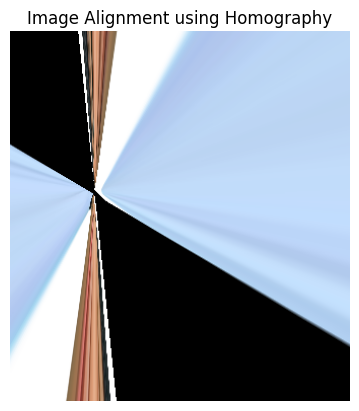

In [3]:
import cv2
import numpy as np  # Import numpy
import matplotlib.pyplot as plt

# Load the two images
image1 = cv2.imread("Juliano.png")
image2 = cv2.imread("Juliano.jpg")

# Convert to grayscale
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# Detect keypoints and descriptors using SIFT
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

# Match features using BFMatcher
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Extract location of good matches
src_pts = np.float32(
    [keypoints1[m.queryIdx].pt for m in good_matches]
).reshape(-1, 1, 2)
dst_pts = np.float32(
    [keypoints2[m.trainIdx].pt for m in good_matches]
).reshape(-1, 1, 2)

# Find homography matrix
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Warp image1 to align with image2
h, w = image1.shape[:2]
result = cv2.warpPerspective(image1, M, (w, h))

# Display the result
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Image Alignment using Homography")
plt.axis('off')
plt.show()


# **Combining Feature Extraction Methods**

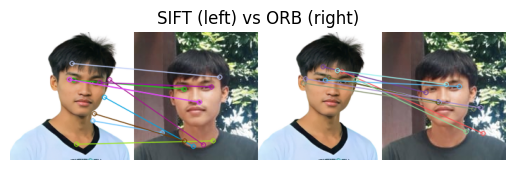

Number of SIFT matches: 50
Number of ORB matches: 88


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the two images
image1 = cv2.imread("Juliano.png")
image2 = cv2.imread("Juliano.jpg")

# Resize both images to the same size (smallest of both)
height1, width1 = image1.shape[:2]
height2, width2 = image2.shape[:2]
new_height = min(height1, height2)
new_width = min(width1, width2)
image1_resized = cv2.resize(image1, (new_width, new_height))
image2_resized = cv2.resize(image2, (new_width, new_height))

# SIFT Detector
sift = cv2.SIFT_create()
keypoints1_sift, descriptors1_sift = sift.detectAndCompute(image1_resized, None)
keypoints2_sift, descriptors2_sift = sift.detectAndCompute(image2_resized, None)

# ORB Detector
orb = cv2.ORB_create()
keypoints1_orb, descriptors1_orb = orb.detectAndCompute(image1_resized, None)
keypoints2_orb, descriptors2_orb = orb.detectAndCompute(image2_resized, None)

# Initialize the Matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match descriptors for SIFT
matches_sift = bf.match(descriptors1_sift, descriptors2_sift)

# Use a different matcher for ORB (since ORB uses binary descriptors)
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf_orb.match(descriptors1_orb, descriptors2_orb)

# Sort matches by distance (Best matches first)
matches_sift = sorted(matches_sift, key=lambda x: x.distance)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)

# Draw the top matches from both methods
image_matches_sift = cv2.drawMatches(image1_resized, keypoints1_sift, image2_resized, keypoints2_sift, matches_sift[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
image_matches_orb = cv2.drawMatches(image1_resized, keypoints1_orb, image2_resized, keypoints2_orb, matches_orb[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Combine the two results into one for visualization
image_combined = np.hstack((image_matches_sift, image_matches_orb))

# Display the combined image
plt.imshow(cv2.cvtColor(image_combined, cv2.COLOR_BGR2RGB))
plt.title("SIFT (left) vs ORB (right)")
plt.axis('off')
plt.show()

# Print the number of matches for each method
print(f"Number of SIFT matches: {len(matches_sift)}")
print(f"Number of ORB matches: {len(matches_orb)}")